In [1]:
from torchinfo import summary
from model import InceptionModel

model = InceptionModel(aux=True, residual=True, num_classes=10)

summary(model, input_size=(1, 3, 218, 178))

Layer (type:depth-idx)                   Output Shape              Param #
InceptionModel                           [1, 10]                   2,174,346
├─ConvBlock: 1-1                         [1, 64, 109, 89]          --
│    └─Conv2d: 2-1                       [1, 64, 109, 89]          9,472
│    └─BatchNorm2d: 2-2                  [1, 64, 109, 89]          128
├─MaxPool2d: 1-2                         [1, 64, 55, 45]           --
├─ConvBlock: 1-3                         [1, 192, 55, 45]          --
│    └─Conv2d: 2-3                       [1, 192, 55, 45]          110,784
│    └─BatchNorm2d: 2-4                  [1, 192, 55, 45]          384
├─MaxPool2d: 1-4                         [1, 192, 28, 23]          --
├─InceptionBlock: 1-5                    [1, 256, 28, 23]          --
│    └─ConvBlock: 2-5                    [1, 64, 28, 23]           --
│    │    └─Conv2d: 3-1                  [1, 64, 28, 23]           12,352
│    │    └─BatchNorm2d: 3-2             [1, 64, 28, 23]        

In [2]:
# Initialize your model
model = InceptionModel(aux=True, residual=True, num_classes=10)

# Calculate total and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel()
                       for p in model.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

Total Parameters: 5,240,092
Trainable Parameters: 5,240,092


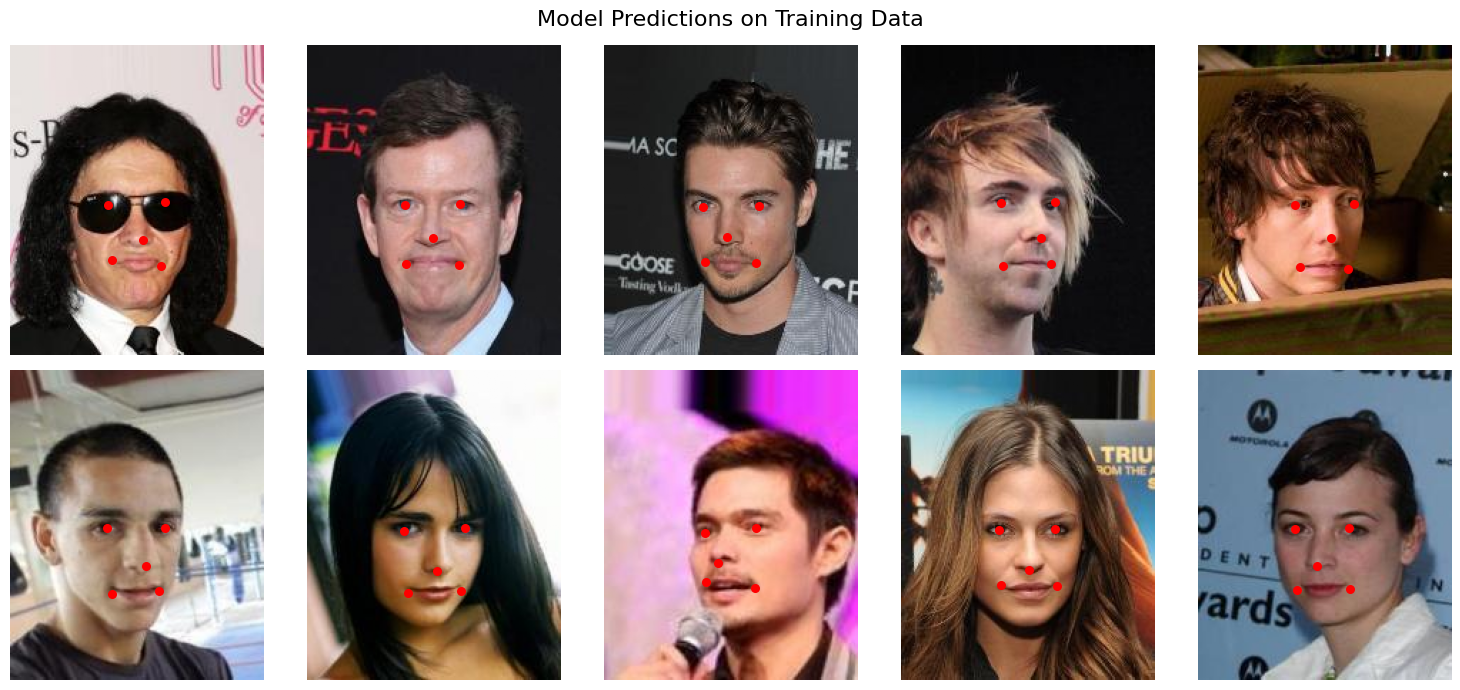

In [3]:
import torch
import torchvision
import numpy as np
import os
import matplotlib.pyplot as plt
from skimage import io
from torch.utils.data import Dataset, DataLoader
from model import InceptionModel


class FaceLandmarksDataset(Dataset):
    def __init__(self, csv_file, img_root_dir, transform=None):
        self.landmarks_frame = []
        with open(csv_file, "r") as file:
            for line in file:
                self.landmarks_frame.append(line.strip().split(","))
        self.landmarks_frame = self.landmarks_frame[2:]
        self.img_root_dir = img_root_dir
        self.transform = transform

    def __len__(self):
        return len(self.landmarks_frame)

    def __getitem__(self, idx):
        img_name = os.path.join(
            self.img_root_dir, self.landmarks_frame[idx][0])
        image = io.imread(img_name)

        if self.transform:
            image_tr = self.transform(image)

        return {'image': image, 'image_tr': image_tr}


transform = torchvision.transforms.Compose([torchvision.transforms.ToTensor()])

dataset = FaceLandmarksDataset(
    "/home/gantumur/Documents/DL/Lab456/data/list_landmarks_align_celeba.csv",
    "/home/gantumur/Documents/DL/Lab456/data/img_align_celeba/img_align_celeba",
    transform=transform
)

loader = DataLoader(dataset, batch_size=10, shuffle=True)
batch_dict = next(iter(loader))
images = batch_dict["image_tr"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = InceptionModel(aux=True, residual=True, num_classes=10).to(device)
model.load_state_dict(torch.load(
    "/home/gantumur/Documents/DL/Lab456/models/best_inception_weights.pth", weights_only=True))
model.eval()

with torch.no_grad():
    predictions = model(images.to(device).float()).cpu().numpy()

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle("Model Predictions on Training Data", fontsize=16)
axes = axes.flatten()

for i in range(10):
    ax = axes[i]
    img = images[i].numpy().transpose(1, 2, 0)
    ax.imshow(img)

    pred_coords = predictions[i]
    for j in range(5):

        pred_x = pred_coords[2 * j] * 178
        pred_y = pred_coords[2 * j + 1] * 218
        ax.scatter(pred_x, pred_y, s=30, c='red', marker='o')

    ax.axis('off')

plt.tight_layout()
plt.show()

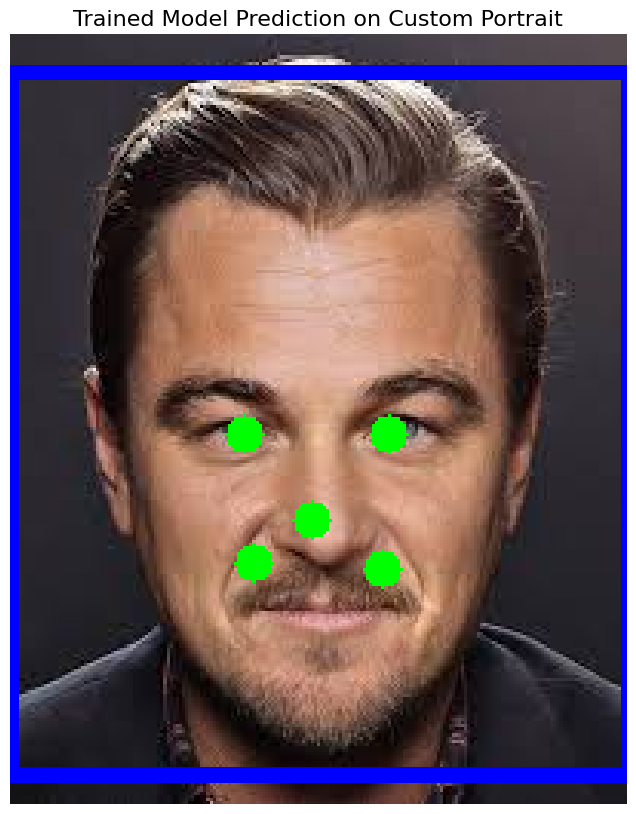

In [4]:
import cv2
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from model import InceptionModel


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = InceptionModel(aux=True, residual=True, num_classes=10).to(device)
weights_path = "/home/gantumur/Documents/DL/Lab456/models/best_inception_weights.pth"

model.load_state_dict(torch.load(
    weights_path, map_location=device, weights_only=True))
model.eval()

transform = transforms.Compose([transforms.ToTensor()])

image_path = "/home/gantumur/Documents/DL/Lab456/test_img.jpeg"

img = cv2.imread(image_path)
if img is None:
    print(f"Error: Could not load image at {image_path}. Check the file path!")
    exit()

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_display = img_rgb.copy()  

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Find faces
faces = face_cascade.detectMultiScale(
    gray, scaleFactor=1.1, minNeighbors=5, minSize=(100, 100))

if len(faces) == 0:
    print("OpenCV could not find a face in this image.")
else:
    with torch.no_grad():
        for (x, y, w, h) in faces:

            pad_w = int(w * 0.25)
            pad_h_top = int(h * 0.40)
            pad_h_bot = int(h * 0.15)

            new_x = max(0, x - pad_w)
            new_y = max(0, y - pad_h_top)
            new_w = min(img.shape[1] - new_x, w + 2 * pad_w)
            new_h = min(img.shape[0] - new_y, h + pad_h_top + pad_h_bot)

            cv2.rectangle(img_display, (new_x, new_y),
                          (new_x + new_w, new_y + new_h), (0, 0, 255), 3)

            face_roi = img_rgb[new_y:new_y+new_h, new_x:new_x+new_w]
            if face_roi.size == 0:
                continue

            face_resized = cv2.resize(face_roi, (178, 218))
            input_tensor = transform(
                face_resized).unsqueeze(0).to(device).float()

            predictions = model(input_tensor).cpu().numpy()[0]

            for i in range(5):
 
                pred_x = int(predictions[2 * i] * new_w) + new_x
                pred_y = int(predictions[2 * i + 1] * new_h) + new_y

                cv2.circle(img_display, (pred_x, pred_y), radius=6,
                           color=(0, 255, 0), thickness=-1)

plt.figure(figsize=(10, 10))
plt.imshow(img_display)
plt.axis('off')
plt.title("Trained Model Prediction on Custom Portrait", fontsize=16)
plt.show()